# Task 002 - Data Preparation

## CRISP-DM Phase 3

---

# مقدمه

در تسک قبلی شما مرحله **Data Understanding** را روی دیتاست بیماری قلبی انجام دادید.

در پایان آن مرحله باید به درک مناسبی از موارد زیر رسیده باشید:

* ساختار داده
* کیفیت داده
* ویژگی‌های مهم
* ارتباط ویژگی‌ها با متغیر هدف
* مشکلات موجود در داده
* مناسب بودن داده برای مدل‌سازی

اکنون وارد مرحله سوم فرآیند CRISP-DM یعنی **Data Preparation** می‌شویم.

---

# یادآوری چالش کسب‌وکار

شما به عنوان تحلیلگر داده در یک مرکز درمانی قلب و عروق فعالیت می‌کنید.

هدف کسب‌وکار:

تشخیص احتمال ابتلا به بیماری قلبی بر اساس ویژگی‌های بیماران.

متغیر هدف:

```python
target
```

* 0 → Healthy
* 1 → Heart Disease

---

# نوع مسئله داده‌کاوی

با توجه به تحلیل مرحله قبل:

متغیر هدف مشخص است و دو کلاس دارد.

بنابراین مسئله اصلی:

## Supervised Learning

و به طور دقیق‌تر:

## Binary Classification

---

# الگوریتم‌های احتمالی آینده

در مراحل بعدی ممکن است از الگوریتم‌های زیر استفاده شود:

* Logistic Regression
* Decision Tree
* Random Forest
* KNN
* SVM
* Naive Bayes

بنابراین باید داده را به شکلی آماده کنیم که برای این الگوریتم‌ها مناسب باشد.

---

# هدف این تسک

ایجاد یک دیتاست نهایی و آماده برای مرحله Modeling

---

# خروجی نهایی مورد انتظار

در پایان این تسک باید فایل زیر را ایجاد کنید:

```python
heart_prepared.csv
```

این فایل باید:

* تمیز باشد
* ویژگی‌های انتخاب شده را داشته باشد
* ویژگی‌های جدید مورد نیاز را داشته باشد
* فرمت مناسبی داشته باشد
* داده‌های عددی مقیاس‌بندی شده باشند
* برای مدل‌سازی آماده باشد

---

# قوانین

- استفاده از Scikit-Learn ممنوع
- استفاده از AutoML ممنوع


فقط از موارد زیر استفاده شود

- NumPy
- Pandas
- Matplotlib
- Seaborn

---

In [244]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [245]:
df = pd.read_csv("heart.csv")

In [246]:
numerical = []
categorical = []
boolian = []
for index , col in enumerate(df.columns):
    number_unique = df[col].nunique()
    if number_unique == 2:
        boolian.append(col)
    elif 6 > number_unique > 2 or df[col].dtype == "object":
        categorical.append(col)
    else:
        numerical.append(col)

# بخش اول

# Data Selection

---

## سوال 1

براساس تحلیل مرحله قبل:

کدام ستون‌ها بیشترین ارتباط را با target داشتند؟

فهرست آن‌ها را استخراج کنید.

---

In [247]:
corr = df.corr()
corr["target"].abs().sort_values(ascending=False)

target      1.000000
exang       0.436757
cp          0.433798
oldpeak     0.430696
thalach     0.421741
ca          0.391724
slope       0.345877
thal        0.344029
sex         0.280937
age         0.225439
trestbps    0.144931
restecg     0.137230
chol        0.085239
fbs         0.028046
Name: target, dtype: float64

به ترتیب 

exang

cp

oldpeak

thalach

ca

## سوال 2

یک جدول تهیه کنید:

| Feature | Business Importance | Data Importance |
| ------- | ------------------- | --------------- |

---

## سوال 3

حداقل سه ویژگی را انتخاب کنید که احتمال می‌دهید برای مدل‌سازی مفید نباشند.

دلایل خود را بنویسید.

---

In [248]:
k2 = []
k2_value = 0
lst = boolian + categorical
for index , col in enumerate(df[lst].columns):
    df_cross = pd.crosstab(df[col],df["target"])
    t_row = df_cross.sum(axis = 1).values
    t_col = df_cross.sum(axis = 0).values
    total = df_cross.sum().sum()
    for i in range(len(df_cross)):
        for j in range(len(df_cross.columns)):
            o = df_cross.iloc[i,j]
            e = (t_row[i] * t_col[j])/total
            x = ((o-e) ** 2)/e
            k2_value += x
    k2.append((col,x))
l = pd.Series(k2)
print(l)
# numerical.append("target")
# df[numerical].groupby("target").agg(["mean","std"])




0         (sex, 3.450835518334441)
1       (fbs, 0.09242524252425258)
2      (exang, 17.723379610688337)
3      (target, 62.85148514851485)
4         (cp, 0.9642781669471296)
5    (restecg, 0.6373087308730875)
6      (slope, 11.386783889656568)
7         (ca, 0.5991359135913589)
8       (thal, 20.018077192334616)
dtype: object


In [249]:
df.corr()["target"].sort_values()

exang      -0.436757
oldpeak    -0.430696
ca         -0.391724
thal       -0.344029
sex        -0.280937
age        -0.225439
trestbps   -0.144931
chol       -0.085239
fbs        -0.028046
restecg     0.137230
slope       0.345877
thalach     0.421741
cp          0.433798
target      1.000000
Name: target, dtype: float64

restecg,fbs,chol,ca
با توجه به همبستگی و کای دو این۴ تا کمترین وابستگی رو دارن

## سوال 4

یک نسخه جدید از دیتاست بسازید که فقط شامل ویژگی‌های منتخب شما باشد.

نام:

```python
selected_df
```

---

In [250]:
selected_df = df.drop(columns = ["restecg","fbs","chol","ca"])

## سوال 5

تعداد ویژگی‌ها قبل و بعد از Selection را مقایسه کنید.

---

In [251]:
print(df.columns)
print(selected_df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')
Index(['age', 'sex', 'cp', 'trestbps', 'thalach', 'exang', 'oldpeak', 'slope',
       'thal', 'target'],
      dtype='str')


# بخش دوم

# Data Cleaning

---

## سوال 6

تمام مقادیر Null را مجدداً بررسی کنید.

---

In [252]:
for index in df.columns:
    print(f"{index} -> {df[index].isna().sum()}")

age -> 0
sex -> 0
cp -> 0
trestbps -> 0
chol -> 0
fbs -> 0
restecg -> 0
thalach -> 0
exang -> 0
oldpeak -> 0
slope -> 0
ca -> 0
thal -> 0
target -> 0


## سوال 7

برای هر ستون مشخص کنید:

* تعداد Null
* درصد Null

---

In [253]:
for col in df.columns:
    print(f"{col} -> {df[col].isna().sum()}")
for col in df.columns:
    print(f"\n{col} -> {df[col].isna().sum()/df.sum() *100}%")


age -> 0
sex -> 0
cp -> 0
trestbps -> 0
chol -> 0
fbs -> 0
restecg -> 0
thalach -> 0
exang -> 0
oldpeak -> 0
slope -> 0
ca -> 0
thal -> 0
target -> 0

age -> age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
target      0.0
dtype: float64%

sex -> age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
target      0.0
dtype: float64%

cp -> age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
target      0.0
dtype: float64%

trestbps -> age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.

## سوال 8

اگر داده گمشده وجود دارد:

سه روش مختلف برای پر کردن آن پیشنهاد دهید.

---

۱.پر کردن با میانگین

۲.پر کردن با میانه

۳.پر کردن با مد

۴.میانگین ردیف بالا و پایین

## سوال 9

یکی از روش‌ها را انتخاب کرده و پیاده‌سازی کنید.

---

## سوال 10

رکوردهای تکراری را شناسایی کنید.

---

In [254]:
df.loc[df.duplicated(keep = False)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


## سوال 11

نسخه‌ای از داده بدون رکوردهای تکراری ایجاد کنید.

---

In [255]:
df = df.drop(index=164)

## سوال 12

با استفاده از Boxplot و IQR:

Outlier های هر ویژگی عددی را پیدا کنید.

---

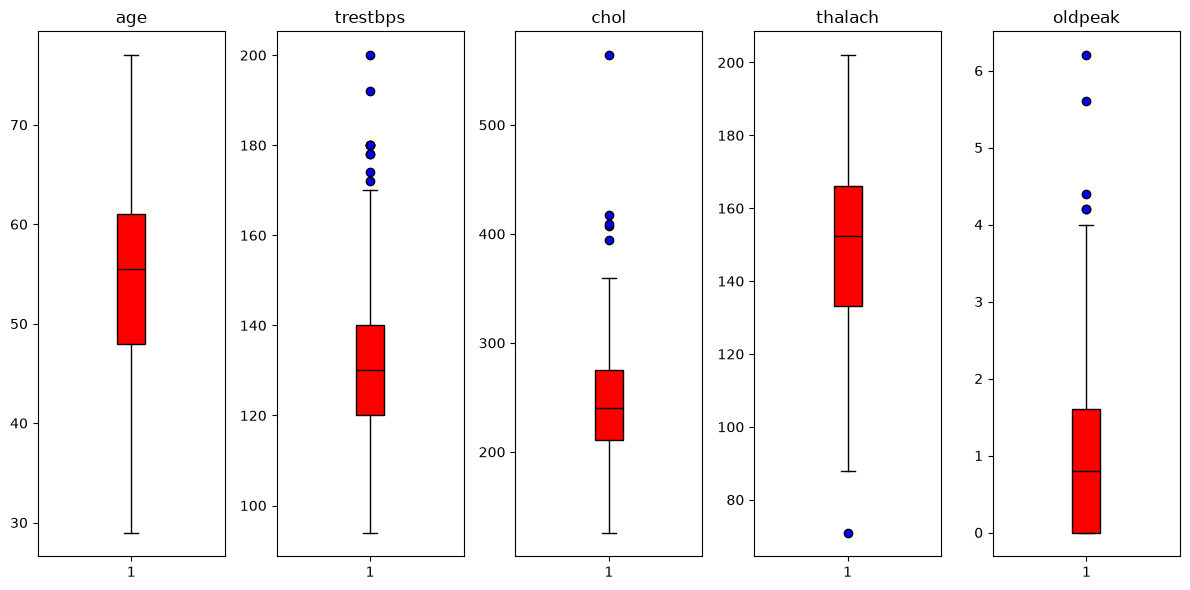

In [256]:
col = numerical
fig , ax = plt.subplots(figsize=(12,6),ncols=len(col))
for i ,column in enumerate(col):
    ax[i].boxplot(df[column],patch_artist=True,boxprops={"facecolor":"red"},medianprops={"color":"black"},flierprops={"markerfacecolor":"blue"})
    ax[i].set_title(column)
plt.tight_layout()

In [257]:
dict_missing = {}
for col in df[numerical]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3-q1
    dict_missing[col] = df[(df[col]> q3 + (iqr * 1.5)) | (df[col] < q1 - (iqr * 1.5))]
for key,value in dict_missing.items():
    print(f"{key}->{len(value)}")


age->0
trestbps->9
chol->5
thalach->1
oldpeak->5


## سوال 13

جدولی ایجاد کنید:

| Feature | Number of Outliers |

---

In [258]:
df_copy = df.copy()
mask = pd.Series(None)
for col in df[numerical]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3-q1
    mask = mask | (df[col]> q3 + (iqr * 1.5)) | (df[col] < q1 - (iqr * 1.5))
    df_copy[col] = df_copy[col].astype(str)
    df_copy.loc[(df[col]> q3 + (iqr * 1.5)) | (df[col] < q1 - (iqr * 1.5)),col] = "*" + df_copy.loc[(df[col]> q3 + (iqr * 1.5)) | (df[col] < q1 - (iqr * 1.5)),col] + "*"
df_copy[mask]


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
8,52,1,2,*172*,199,1,1,162,0,0.5,2,0,3,1
28,65,0,2,140,*417*,1,0,157,0,0.8,2,1,2,1
85,67,0,2,115,*564*,0,0,160,0,1.6,1,0,3,1
96,62,0,0,140,*394*,0,0,157,0,1.2,1,0,2,1
101,59,1,3,*178*,270,0,0,145,0,*4.2*,0,0,3,1
110,64,0,0,*180*,325,0,1,154,1,0.0,2,0,2,1
203,68,1,2,*180*,274,1,0,150,1,1.6,1,0,3,0
204,62,0,0,160,164,0,0,145,0,*6.2*,0,3,3,0
220,63,0,0,150,*407*,0,0,154,0,4.0,1,3,3,0
221,55,1,0,140,217,0,1,111,1,*5.6*,0,0,3,0


## سوال 14

برای Outlier ها سه استراتژی مختلف پیشنهاد دهید.

۱.حذف داده پرت

۲.لگاریتم یا جذر گرفتن از اون ستون

۳.جایگزینی با سقف داده ها یعنی q3 + iqr *1.5

4.جایگزینی با میانگین یا میانه انگار داده گمشده است


---

## سوال 15

یک استراتژی را انتخاب و پیاده‌سازی کنید.

---

In [259]:
df = df[~mask]

# بخش سوم

# Data Construction

---

در این بخش باید ویژگی‌های جدید ایجاد شوند.

---

## سوال 16

سن را به سه گروه تقسیم کنید:

* Young
* Middle Age
* Senior

ستون جدید:

```python
age_group
```

---

In [260]:
age_categorical = []
for index in df["age"]:
    if index < 18:
        index = "young"
        age_categorical.append(index)
    elif 40 > index:
        index = "middle age"
        age_categorical.append(index)
    else:
        index = "senior"
        age_categorical.append(index)
df.insert(1,"age_group",age_categorical)
df

,age,age_group,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,senior,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,middle age,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,senior,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,senior,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,senior,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,senior,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,senior,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,senior,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,senior,1,0,130,131,0,1,115,1,1.2,1,1,3,0


## سوال 17

برای chol سطح ریسک ایجاد کنید:

* Low
* Normal
* High

---

In [261]:
chol_categorical = []
for index in df["chol"]:
    if index < 120:
        index = "Low"
        chol_categorical.append(index)
    elif 200 > index:
        index = "Normal"
        chol_categorical.append(index)
    else:
        index = "High"
        chol_categorical.append(index)
df.insert(6,"chol risk",chol_categorical)
df

,age,age_group,sex,cp,trestbps,chol,chol risk,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,senior,1,3,145,233,High,1,0,150,0,2.3,0,0,1,1
1,37,middle age,1,2,130,250,High,0,1,187,0,3.5,0,0,2,1
2,41,senior,0,1,130,204,High,0,0,172,0,1.4,2,0,2,1
3,56,senior,1,1,120,236,High,0,1,178,0,0.8,2,0,2,1
4,57,senior,0,0,120,354,High,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,senior,0,0,140,241,High,0,1,123,1,0.2,1,0,3,0
299,45,senior,1,3,110,264,High,0,1,132,0,1.2,1,0,3,0
300,68,senior,1,0,144,193,Normal,1,1,141,0,3.4,1,2,3,0
301,57,senior,1,0,130,131,Normal,0,1,115,1,1.2,1,1,3,0


## سوال 18

برای trestbps سطح فشار خون تعریف کنید.

---

In [262]:
trestbps_categorical = []
for index in df["trestbps"]:
    if index < 120:
        index = "Normal"
        trestbps_categorical.append(index)
    elif 200 > index:
        index = "Elavated"
        trestbps_categorical.append(index)
    else:
        index = "Hypertention"
        chol_categorical.append(index)
df.insert(5,"trestbps risk",trestbps_categorical)
df

,age,age_group,sex,cp,trestbps,trestbps risk,chol,chol risk,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,senior,1,3,145,Elavated,233,High,1,0,150,0,2.3,0,0,1,1
1,37,middle age,1,2,130,Elavated,250,High,0,1,187,0,3.5,0,0,2,1
2,41,senior,0,1,130,Elavated,204,High,0,0,172,0,1.4,2,0,2,1
3,56,senior,1,1,120,Elavated,236,High,0,1,178,0,0.8,2,0,2,1
4,57,senior,0,0,120,Elavated,354,High,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,senior,0,0,140,Elavated,241,High,0,1,123,1,0.2,1,0,3,0
299,45,senior,1,3,110,Normal,264,High,0,1,132,0,1.2,1,0,3,0
300,68,senior,1,0,144,Elavated,193,Normal,1,1,141,0,3.4,1,2,3,0
301,57,senior,1,0,130,Elavated,131,Normal,0,1,115,1,1.2,1,1,3,0


## سوال 19

حداقل دو Feature جدید طراحی کنید.

دلایل کسب‌وکاری آن را توضیح دهید.

---

## سوال 20

جدول زیر را تکمیل کنید:

| New Feature | Business Reason |

---

# بخش چهارم

# Data Integration

---

فرض کنید داده جدیدی از آزمایشگاه دریافت شده است.

فایل فرضی:

```python
lab_results.csv
```

---

In [263]:
df_lab = pd.read_csv("lab_results.csv")


## سوال 21

یک DataFrame آزمایشی بسازید.

---

In [264]:
df_lab = df_lab.drop(columns=["Pregnancies","BloodPressure","Age","DiabetesPedigreeFunction"])
df_lab_sample = df_lab.sample(n=303,random_state= 42)

## سوال 22

یک کلید مشترک تعریف کنید.

---

In [265]:
df_lab_sample = df_lab_sample.reset_index(drop=True)
df_lab_sample["index"] = df_lab_sample.index
df["index"] = df.index
df_lab_sample

,Glucose,SkinThickness,Insulin,BMI,Outcome,index
0,98,33,190,34.0,0,0
1,112,32,0,35.7,0,1
2,108,0,0,30.8,0,2
3,107,0,0,24.6,0,3
4,136,0,0,29.9,0,4
...,...,...,...,...,...,...
298,100,0,0,30.0,1,298
299,126,38,75,25.9,0,299
300,111,39,0,30.1,0,300
301,144,26,285,32.0,1,301


## سوال 23

Merge را انجام دهید.

---

## سوال 24

انواع Merge زیر را مقایسه کنید:

* inner
* left
* right
* outer

---

In [266]:
df_merge_left = pd.merge(df,df_lab_sample,on="index",how="left")
df_merge_right = pd.merge(df,df_lab_sample,on="index",how="right")
df_merge_inner = pd.merge(df,df_lab_sample,on="index",how="inner")
df_merge_outer= pd.merge(df,df_lab_sample,on="index",how="outer")


## سوال 25

مشخص کنید برای این پروژه کدام نوع Merge مناسب‌تر است.

---

In [267]:
df = df_merge_left

# بخش پنجم

# Data Formatting

---

## سوال 26

نوع داده تمامی ستون‌ها را بررسی کنید.

---

In [268]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 283 entries, 0 to 282
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            283 non-null    int64  
 1   age_group      283 non-null    str    
 2   sex            283 non-null    int64  
 3   cp             283 non-null    int64  
 4   trestbps       283 non-null    int64  
 5   trestbps risk  283 non-null    str    
 6   chol           283 non-null    int64  
 7   chol risk      283 non-null    str    
 8   fbs            283 non-null    int64  
 9   restecg        283 non-null    int64  
 10  thalach        283 non-null    int64  
 11  exang          283 non-null    int64  
 12  oldpeak        283 non-null    float64
 13  slope          283 non-null    int64  
 14  ca             283 non-null    int64  
 15  thal           283 non-null    int64  
 16  target         283 non-null    int64  
 17  index          283 non-null    int64  
 18  Glucose        283 no

## سوال 27

ستون‌هایی که باید Category باشند را شناسایی کنید.

---

In [269]:
numerical = []
categorical = []
boolian = []
for index , col in enumerate(df.columns):
    if df[col].dtype != "object":
        number_unique = df[col].nunique()
        if number_unique == 2:
            boolian.append(col)
        elif 6 > number_unique > 2:
            categorical.append(col)
        else:
            numerical.append(col)

## سوال 28

Datatype مناسب را اعمال کنید.

---

In [270]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 283 entries, 0 to 282
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            283 non-null    int64  
 1   age_group      283 non-null    str    
 2   sex            283 non-null    int64  
 3   cp             283 non-null    int64  
 4   trestbps       283 non-null    int64  
 5   trestbps risk  283 non-null    str    
 6   chol           283 non-null    int64  
 7   chol risk      283 non-null    str    
 8   fbs            283 non-null    int64  
 9   restecg        283 non-null    int64  
 10  thalach        283 non-null    int64  
 11  exang          283 non-null    int64  
 12  oldpeak        283 non-null    float64
 13  slope          283 non-null    int64  
 14  ca             283 non-null    int64  
 15  thal           283 non-null    int64  
 16  target         283 non-null    int64  
 17  index          283 non-null    int64  
 18  Glucose        283 no

In [271]:
for col in df[categorical]:
    df[col] = df[col].astype("category")

## سوال 29

حجم حافظه قبل و بعد از تغییر datatype را مقایسه کنید.

---

In [272]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 283 entries, 0 to 282
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   age            283 non-null    int64   
 1   age_group      283 non-null    str     
 2   sex            283 non-null    int64   
 3   cp             283 non-null    category
 4   trestbps       283 non-null    int64   
 5   trestbps risk  283 non-null    str     
 6   chol           283 non-null    int64   
 7   chol risk      283 non-null    str     
 8   fbs            283 non-null    int64   
 9   restecg        283 non-null    category
 10  thalach        283 non-null    int64   
 11  exang          283 non-null    int64   
 12  oldpeak        283 non-null    float64 
 13  slope          283 non-null    category
 14  ca             283 non-null    category
 15  thal           283 non-null    category
 16  target         283 non-null    int64   
 17  index          283 non-null    int64   
 18  G

## سوال 30

ستون‌های متنی را استانداردسازی کنید.

مثال:

```python
Male
male
MALE
```

---

In [273]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.title()
df
    

/tmp/ipykernel_4860/1387291106.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


,age,age_group,sex,cp,trestbps,trestbps risk,chol,chol risk,fbs,restecg,...,slope,ca,thal,target,index,Glucose,SkinThickness,Insulin,BMI,Outcome
0,63,Senior,1,3,145,Elavated,233,High,1,0,...,0,0,1,1,0,98,33,190,34.0,0
1,37,Middle Age,1,2,130,Elavated,250,High,0,1,...,0,0,2,1,1,112,32,0,35.7,0
2,41,Senior,0,1,130,Elavated,204,High,0,0,...,2,0,2,1,2,108,0,0,30.8,0
3,56,Senior,1,1,120,Elavated,236,High,0,1,...,2,0,2,1,3,107,0,0,24.6,0
4,57,Senior,0,0,120,Elavated,354,High,0,1,...,2,0,2,1,4,136,0,0,29.9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,57,Senior,0,0,140,Elavated,241,High,0,1,...,1,0,3,0,298,100,0,0,30.0,1
279,45,Senior,1,3,110,Normal,264,High,0,1,...,1,0,3,0,299,126,38,75,25.9,0
280,68,Senior,1,0,144,Elavated,193,Normal,1,1,...,1,2,3,0,300,111,39,0,30.1,0
281,57,Senior,1,0,130,Elavated,131,Normal,0,1,...,1,1,3,0,301,144,26,285,32.0,1


# بخش ششم

# Data Reduction

---

## سوال 31

ویژگی‌های دارای واریانس بسیار کم را شناسایی کنید.

---

In [274]:
df[numerical].var().sort_values()

oldpeak              1.053498
BMI                 71.647476
age                 83.323785
trestbps           236.784227
SkinThickness      286.597599
thalach            514.909831
Glucose            971.269027
chol              1993.996491
index             7634.703656
Insulin          12871.550234
dtype: float64

## سوال 32

ویژگی‌های بسیار همبسته را شناسایی کنید.

---

In [275]:
lst = df.drop(columns="index").select_dtypes(exclude="object").columns
corr_matrix = df[lst].corr().abs()
mask = corr_matrix == 1
corr_matrix = corr_matrix[~mask]
for i in range(len(corr_matrix)):
    for j in range(i+1):
        corr_matrix.iloc[i,j] = np.nan
corr_matrix.unstack().dropna().sort_values(ascending=False)

slope          oldpeak          0.525142
Outcome        Glucose          0.482809
Insulin        SkinThickness    0.469847
target         oldpeak          0.434108
               exang            0.431599
                                  ...   
Glucose        ca               0.002525
exang          trestbps         0.001726
SkinThickness  fbs              0.001499
               sex              0.000996
Insulin        trestbps         0.000396
Length: 171, dtype: float64

## سوال 33

Heatmap جدید رسم کنید.

---

[Text(0, 0, 'age'),
 Text(0, 1, 'sex'),
 Text(0, 2, 'cp'),
 Text(0, 3, 'trestbps'),
 Text(0, 4, 'chol'),
 Text(0, 5, 'fbs'),
 Text(0, 6, 'restecg'),
 Text(0, 7, 'thalach'),
 Text(0, 8, 'exang'),
 Text(0, 9, 'oldpeak'),
 Text(0, 10, 'slope'),
 Text(0, 11, 'ca'),
 Text(0, 12, 'thal'),
 Text(0, 13, 'target'),
 Text(0, 14, 'Glucose'),
 Text(0, 15, 'SkinThickness'),
 Text(0, 16, 'Insulin'),
 Text(0, 17, 'BMI'),
 Text(0, 18, 'Outcome')]

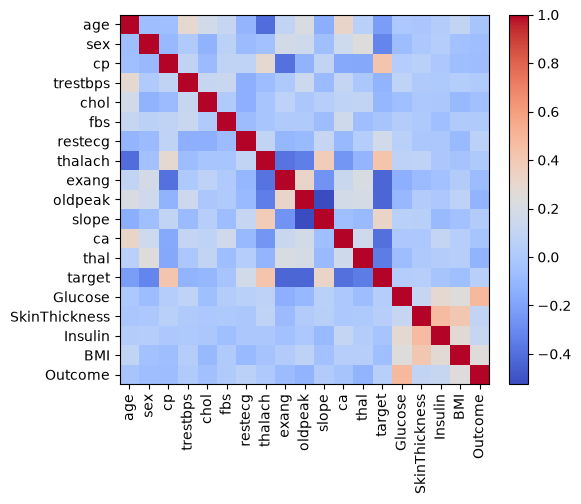

In [276]:
corr_matrix =df[lst].corr()
fig ,ax = plt.subplots()
img = ax.imshow(corr_matrix,cmap="coolwarm")
cbar = fig.colorbar(img,ax=ax,fraction = 0.05 , pad = 0.04)
ax.set_xticks(np.arange(len(df[lst].columns)))
ax.set_yticks(np.arange(len(df[lst].columns)))
ax.set_xticklabels(df[lst].columns,rotation = 90)
ax.set_yticklabels(df[lst].columns)

## سوال 34

اگر دو ویژگی همبستگی بالای 0.85 دارند:

کدام را حذف می‌کنید؟

چرا؟

---

## سوال 35

یک نسخه کاهش‌یافته از دیتاست ایجاد کنید.

نام:

```python
reduced_df
```

---

In [277]:
df.select_dtypes(exclude=object).corr()["target"].sort_values()
df

,age,age_group,sex,cp,trestbps,trestbps risk,chol,chol risk,fbs,restecg,...,slope,ca,thal,target,index,Glucose,SkinThickness,Insulin,BMI,Outcome
0,63,Senior,1,3,145,Elavated,233,High,1,0,...,0,0,1,1,0,98,33,190,34.0,0
1,37,Middle Age,1,2,130,Elavated,250,High,0,1,...,0,0,2,1,1,112,32,0,35.7,0
2,41,Senior,0,1,130,Elavated,204,High,0,0,...,2,0,2,1,2,108,0,0,30.8,0
3,56,Senior,1,1,120,Elavated,236,High,0,1,...,2,0,2,1,3,107,0,0,24.6,0
4,57,Senior,0,0,120,Elavated,354,High,0,1,...,2,0,2,1,4,136,0,0,29.9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,57,Senior,0,0,140,Elavated,241,High,0,1,...,1,0,3,0,298,100,0,0,30.0,1
279,45,Senior,1,3,110,Normal,264,High,0,1,...,1,0,3,0,299,126,38,75,25.9,0
280,68,Senior,1,0,144,Elavated,193,Normal,1,1,...,1,2,3,0,300,111,39,0,30.1,0
281,57,Senior,1,0,130,Elavated,131,Normal,0,1,...,1,1,3,0,301,144,26,285,32.0,1


In [278]:
df = df.drop(columns=["restecg","fbs","chol","chol risk","BMI","Insulin","Glucose","SkinThickness","Outcome","index"])
df

,age,age_group,sex,cp,trestbps,trestbps risk,thalach,exang,oldpeak,slope,ca,thal,target
0,63,Senior,1,3,145,Elavated,150,0,2.3,0,0,1,1
1,37,Middle Age,1,2,130,Elavated,187,0,3.5,0,0,2,1
2,41,Senior,0,1,130,Elavated,172,0,1.4,2,0,2,1
3,56,Senior,1,1,120,Elavated,178,0,0.8,2,0,2,1
4,57,Senior,0,0,120,Elavated,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,57,Senior,0,0,140,Elavated,123,1,0.2,1,0,3,0
279,45,Senior,1,3,110,Normal,132,0,1.2,1,0,3,0
280,68,Senior,1,0,144,Elavated,141,0,3.4,1,2,3,0
281,57,Senior,1,0,130,Elavated,115,1,1.2,1,1,3,0


# بخش هفتم

# Data Transformation

---

# Normalization & Scaling

---

## سوال 36

بررسی کنید آیا ویژگی‌های عددی مقیاس‌های متفاوت دارند یا خیر.

---

## سوال 37

برای تمام ویژگی‌های عددی:

Min-Max Scaling را با NumPy پیاده‌سازی کنید.

فرمول:

```python
(x-min)/(max-min)
```

---

In [279]:
numerical = []
categorical = []
boolian = []
for index , col in enumerate(df.columns):
    number_unique = df[col].nunique()
    if number_unique == 2:
        boolian.append(col)
    elif 6 > number_unique > 2 or df[col].dtype == "object":
        categorical.append(col)
    else:
        numerical.append(col)
for col in df[numerical]:
    x_max = df[col].max()
    x_min = df[col].min()
    min_max = (df[col] - x_min) / (x_max - x_min)

## سوال 38

برای تمام ویژگی‌های عددی:

Standardization را با NumPy پیاده‌سازی کنید.

---

In [280]:
numerical = []
categorical = []
boolian = []
for index , col in enumerate(df.columns):
    number_unique = df[col].nunique()
    if number_unique == 2:
        boolian.append(col)
    elif 6 > number_unique > 2 or df[col].dtype == "object":
        categorical.append(col)
    else:
        numerical.append(col)
for col in df[numerical]:
    x_mean = df[col].mean()
    x_std = df[col].std()
    z_score = (df[col] - x_mean) / x_std
    

## سوال 39

قبل و بعد از Scaling:

Histogram رسم کنید.

---

## سوال 40

مقایسه کنید:

* MinMax
* Standardization

برای این پروژه کدام مناسب‌تر است؟

---

In [281]:

for col in df[numerical]:
    x_mean = df[col].mean()
    x_std = df[col].std()
    z_score = (df[col] - x_mean) / x_std
    df[col] = z_score
df

,age,age_group,sex,cp,trestbps,trestbps risk,thalach,exang,oldpeak,slope,ca,thal,target
0,0.980538,Senior,1,3,0.982376,Elavated,0.001713,0,1.313383,0,0,1,1
1,-1.867783,Middle Age,1,2,0.007578,Elavated,1.632270,0,2.482517,0,0,2,1
2,-1.429580,Senior,0,1,0.007578,Elavated,0.971234,0,0.436532,2,0,2,1
3,0.213682,Senior,1,1,-0.642288,Elavated,1.235648,0,-0.148035,2,0,2,1
4,0.323233,Senior,0,0,-0.642288,Elavated,0.574612,1,-0.342891,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,0.323233,Senior,0,0,0.657444,Elavated,-1.188153,1,-0.732602,1,0,3,0
279,-0.991377,Senior,1,3,-1.292153,Normal,-0.791531,0,0.241676,1,0,3,0
280,1.528292,Senior,1,0,0.917390,Elavated,-0.394909,0,2.385089,1,2,3,0
281,0.323233,Senior,1,0,0.007578,Elavated,-1.540706,1,0.241676,1,1,3,0


# بخش هشتم

# Dataset Validation

---

## سوال 41

شکل نهایی دیتاست را گزارش کنید.

---

## سوال 42

آیا Null باقی مانده است؟

---

## سوال 43

آیا Duplicate باقی مانده است؟

---

## سوال 44

آیا Outlier ها مدیریت شده‌اند؟

---

## سوال 45

آیا تمامی ویژگی‌ها فرمت مناسبی دارند؟

---

## سوال 46

آیا داده برای KNN مناسب است؟

توضیح دهید.

---

## سوال 47

آیا داده برای Logistic Regression مناسب است؟

توضیح دهید.

---

## سوال 48

آیا داده برای Decision Tree مناسب است؟

توضیح دهید.

---

## سوال 49

دیتاست نهایی را ذخیره کنید:

```python
heart_prepared.csv
```

---

## سوال 50

یک گزارش مدیریتی تهیه کنید.

به سوالات زیر پاسخ دهید:

1. چه تغییراتی روی داده انجام شد؟
2. چه ویژگی‌هایی حذف شدند؟
3. چه ویژگی‌هایی ساخته شدند؟
4. چه مشکلاتی برطرف شد؟
5. آیا داده برای Modeling آماده است؟

---

# تحویل پروژه

فایل‌های زیر باید ارسال شوند:

```python
task002_data_preparation.ipynb
heart_prepared.csv
```

---

# هدف آموزشی این تسک

پس از پایان این تمرین دانشجو باید بتواند:

✅ Data Selection انجام دهد

✅ Data Cleaning انجام دهد

✅ Feature Construction انجام دهد

✅ Data Integration انجام دهد

✅ Data Formatting انجام دهد

✅ Data Reduction انجام دهد

✅ Scaling و Normalization انجام دهد

✅ یک دیتاست خام را به یک دیتاست آماده مدل‌سازی تبدیل کند

این دقیقاً خروجی مورد انتظار مرحله Data Preparation در فرآیند CRISP-DM است.